**Endpoint Security Analytics
on Mobile Devices**

-----

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

---

Task 1: Data Collection

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving full_phone_log.log to full_phone_log.log



---

Task 2: Data Parsing and Preprocessing

In [ ]:
# Use the provided Python script to parse the raw log file into a DataFrame with columns: Timestamp, EventType, Source, Details.

log_file = "full_phone_log.log"
data = []

patterns = {
    "app_launch": re.compile(r"(Activity|onResume|onCreate)", re.IGNORECASE),
    "network_connection": re.compile(r"(network|http|ssl|tcp|udp|ip\b)", re.IGNORECASE),
    "auth_failure": re.compile(r"(auth|login\sfailed|authentication)", re.IGNORECASE),
    "permission_change": re.compile(r"(permission)", re.IGNORECASE)
}

with open(log_file, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        # timestamp
        ts_match = re.match(r"(\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d+)", line)

        # Handle missing values (by skipping data withou timestamp)
        if not ts_match:
            continue
        timestamp = ts_match.group(1)

        # source tag
        src_match = re.search(r"\d+\s+\d+\s+\w\s+([\w\[\]#\.\-]+):", line)
        source = src_match.group(1) if src_match else "unknown"

        # details
        details_match = re.search(r":\s*(.*)", line)
        details = details_match.group(1).strip() if details_match else "none"

        # EventType
        event_type = "other"
        for etype, pattern in patterns.items():
            if pattern.search(line):
                event_type = etype
                break

        data.append([timestamp, event_type, source, details])

# Create DataFrame
df = pd.DataFrame(data, columns=["Timestamp", "EventType", "Source", "Details"])

# extract the hour of day (converting timestamp to datetime)
df["Timestamp"] = pd.to_datetime("2025-" + df["Timestamp"], format="%Y-%m-%d %H:%M:%S.%f", errors="coerce")
df["Hour"] = df["Timestamp"].dt.hour

# encode categorical fields (EventType, Source) using one-hot encoding
df = pd.get_dummies(df, columns=["EventType", "Source"], drop_first=False)

display(df)

,Timestamp,Details,Hour,EventType_app_launch,EventType_network_connection,EventType_other,EventType_permission_change,Source_.screenrecorder,Source_ActivityThread,Source_AndroidRuntime,...,Source_ion.cloudserver,Source_linker64,Source_nativeloader,Source_on.smartmessage,Source_pool-24-thread-,Source_pool-9-thread-1,Source_sion.dynamicbar,Source_sion.healthlife,Source_ssioncontroller,Source_unknown
0,2025-08-05 23:11:09.821,11:09.821 9885 9885 D TranActivityAppturboIm...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2025-08-05 23:11:09.880,11:09.880 9885 14260 D BLASTBufferQueue: [VRI...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2025-08-05 23:11:09.892,11:09.892 9885 19241 D CCodecBuffers: [c2.and...,23,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2025-08-05 23:11:09.905,11:09.905 9885 9885 D InputMethodManager: in...,23,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2025-08-05 23:11:09.913,11:09.913 9885 19241 D PipelineWatcher: [0xb4...,23,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8826,2025-08-08 18:24:42.727,24:42.727 12672 12672 W linker64: type=1400 au...,18,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
8827,2025-08-08 18:24:42.727,24:42.727 12672 12672 W linker64: type=1400 au...,18,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
8828,2025-08-08 18:24:42.727,24:42.727 12672 12672 W linker64: type=1400 au...,18,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
8829,2025-08-08 18:24:42.727,24:42.727 12672 12672 W linker64: type=1400 au...,18,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [ ]:
# Output a preprocessed CSV (preprocessed_logs.csv)

df.to_csv("preprocessed_logs.csv", index=False)
print(f"Done. Parsed {len(df)} events into preprocessed_logs.csv")

Done. Parsed 8831 events into preprocessed_logs.csv



---

Task 3: Time-Series Analysis

In [ ]:
# Grouping events by hour and EventType to count occurrences.
event_type_cols = [col for col in df.columns if col.startswith('EventType_')]
df['HourTimestamp'] = df['Timestamp'].dt.floor('H')
hourly_counts = df.groupby('HourTimestamp')[event_type_cols].sum()

# Calculate rolling average with window=3 hours
rolling_avg = hourly_counts.rolling(window=3, min_periods=1).mean()

/tmp/ipython-input-2221758986.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df['HourTimestamp'] = df['Timestamp'].dt.floor('H')


In [ ]:
hourly_counts

,EventType_app_launch,EventType_network_connection,EventType_other,EventType_permission_change
HourTimestamp,,,,
2025-08-05 23:00:00,21,0,454,0
2025-08-06 04:00:00,4,0,101,0
2025-08-06 05:00:00,49,2,1641,0
2025-08-06 06:00:00,0,0,129,0
2025-08-06 07:00:00,0,0,214,0
2025-08-06 08:00:00,0,0,155,0
2025-08-06 09:00:00,0,0,172,0
2025-08-06 10:00:00,0,0,59,1
2025-08-06 11:00:00,0,0,20,0


In [ ]:
rolling_avg

,EventType_app_launch,EventType_network_connection,EventType_other,EventType_permission_change
HourTimestamp,,,,
2025-08-05 23:00:00,21.000000,0.000000,454.000000,0.000000
2025-08-06 04:00:00,12.500000,0.000000,277.500000,0.000000
2025-08-06 05:00:00,24.666667,0.666667,732.000000,0.000000
2025-08-06 06:00:00,17.666667,0.666667,623.666667,0.000000
2025-08-06 07:00:00,16.333333,0.666667,661.333333,0.000000
2025-08-06 08:00:00,0.000000,0.000000,166.000000,0.000000
2025-08-06 09:00:00,0.000000,0.000000,180.333333,0.000000
2025-08-06 10:00:00,0.000000,0.000000,128.666667,0.333333
2025-08-06 11:00:00,0.000000,0.000000,83.666667,0.333333


In [ ]:
# Output CSVs for aggregated counts (time_series.csv) and rolling averages (time_series_rolling.csv)
hourly_counts.to_csv('time_series.csv')
rolling_avg.to_csv('time_series_rolling.csv')
print("Done. Outputted time_series.csv and time_series_rolling.csv")

Done. Outputted time_series.csv and time_series_rolling.csv


---

Task 4: Visualization

png saved


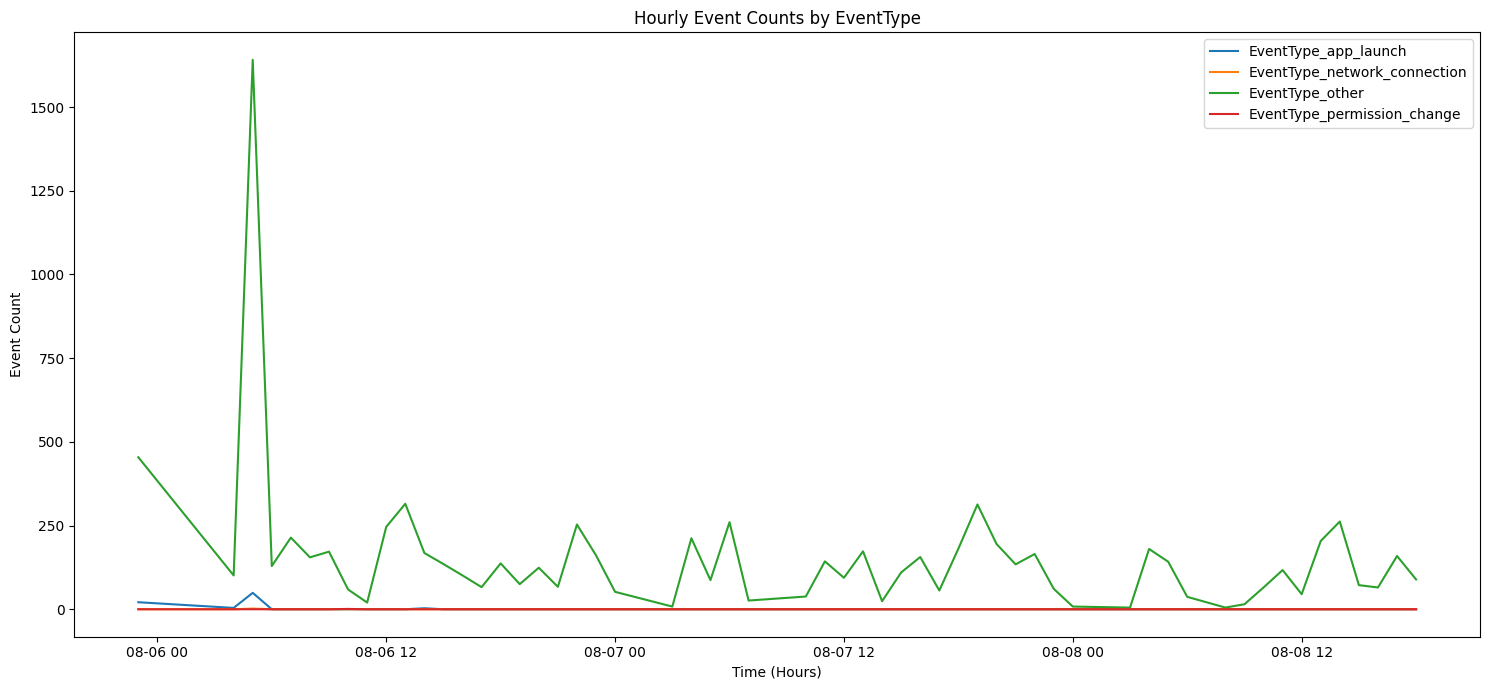

In [18]:
# Create a time-series plot of event counts by hour

plt.figure(figsize=(15, 7))
for col in hourly_counts.columns:
    plt.plot(hourly_counts.index, hourly_counts[col], label=col)

plt.title('Hourly Event Counts by EventType')
plt.xlabel('Time (Hours)')
plt.ylabel('Event Count')
plt.legend(loc='upper right')
plt.tight_layout()

# Save: time_series_plot.png (time-series graph)
plt.savefig('time_series_plot.png')
print('png saved')

plt.show()

png saved


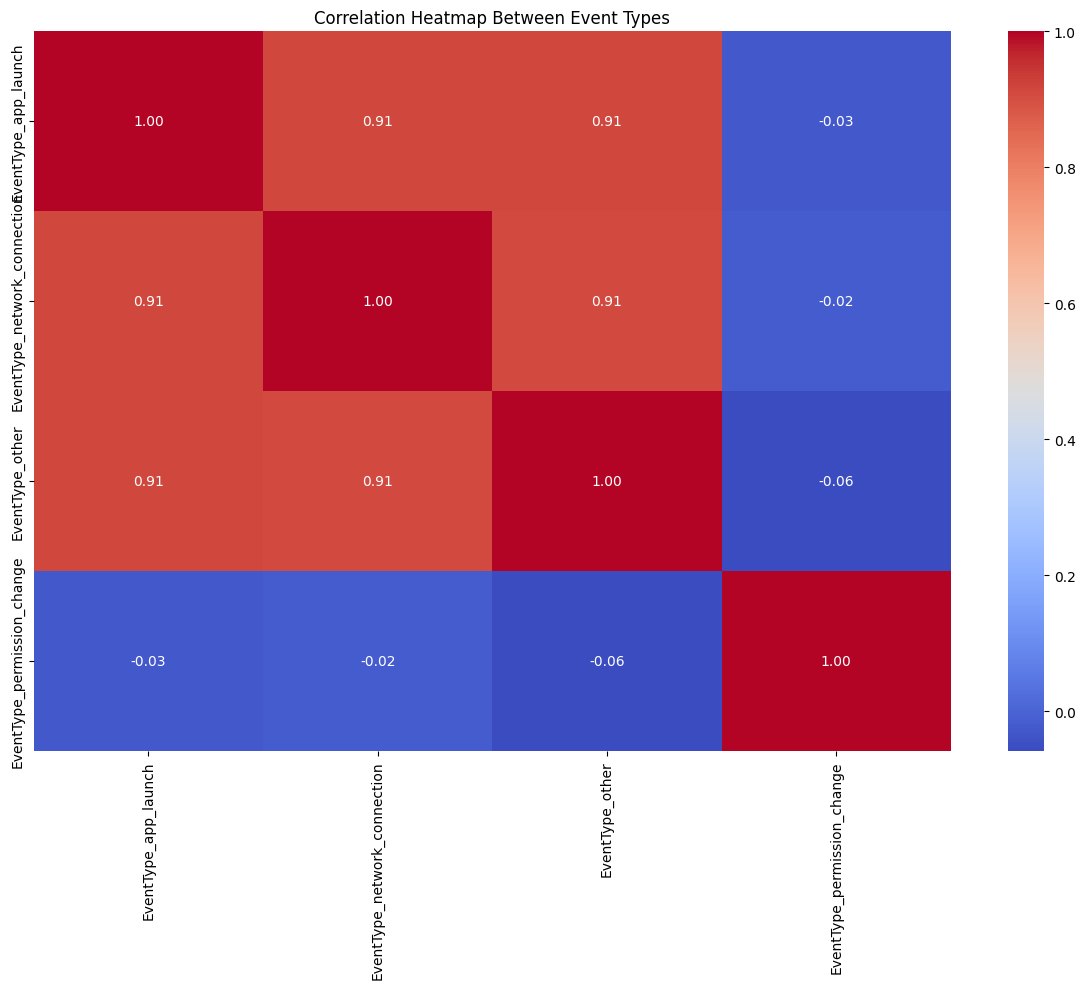

In [19]:
# Create a heatmap of correlations between event types

corr = hourly_counts.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap Between Event Types')
plt.tight_layout()

# Save: heatmap.png (correlation heatmap)
plt.savefig('heatmap.png')
print('png saved')

plt.show()

---

Task 5: Machine Learning for Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest

# Use features from preprocessed_logs.csv
pre_df = pd.read_csv('preprocessed_logs.csv')
eventtype_cols = [col for col in pre_df.columns if col.startswith('EventType_')]
source_cols = [col for col in pre_df.columns if col.startswith('Source_')]

features = ['Hour'] + eventtype_cols + source_cols

X = pre_df[features]

# Apply an Isolation Forest to identify anomalies
iso_forest = IsolationForest(contamination='auto', random_state=42)
pre_df['anomaly'] = iso_forest.fit_predict(X)

# pre_df['anomaly'] = -1 means anomaly
# pre_df['anomaly'] = 1 means normal
anomalies = pre_df[pre_df['anomaly'] == -1]

In [ ]:
anomalies

,Timestamp,Details,Hour,EventType_app_launch,EventType_network_connection,EventType_other,EventType_permission_change,Source_.screenrecorder,Source_ActivityThread,Source_AndroidRuntime,...,Source_linker64,Source_nativeloader,Source_on.smartmessage,Source_pool-24-thread-,Source_pool-9-thread-1,Source_sion.dynamicbar,Source_sion.healthlife,Source_ssioncontroller,Source_unknown,anomaly
0,2025-08-05 23:11:09.821,11:09.821 9885 9885 D TranActivityAppturboIm...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
1,2025-08-05 23:11:09.880,11:09.880 9885 14260 D BLASTBufferQueue: [VRI...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
30,2025-08-05 23:11:27.540,11:27.540 9885 9885 D BLASTBufferQueue: [VRI...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
31,2025-08-05 23:11:27.540,11:27.540 9885 9885 D BufferQueueConsumer: [...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
38,2025-08-05 23:11:34.111,11:34.111 9885 9885 D TranActivityAppturboIm...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
53,2025-08-05 23:11:34.138,11:34.138 9885 14260 D BLASTBufferQueue: [VRI...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
135,2025-08-05 23:11:37.976,11:37.976 9885 9885 D BLASTBufferQueue: [VRI...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
136,2025-08-05 23:11:37.976,11:37.976 9885 9885 D BufferQueueConsumer: [...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
147,2025-08-05 23:14:35.161,14:35.161 9885 9885 D TranActivityAppturboIm...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1
163,2025-08-05 23:14:35.186,14:35.186 9885 14260 D BLASTBufferQueue: [VRI...,23,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,-1


In [ ]:
# A CSV file (anomalies.csv) with detected anomalies.
anomalies.to_csv('anomalies.csv', index=False)
print("Done. Outputted anomalies.csv")

Done. Outputted anomalies.csv
